In [64]:
import pandas as pd
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

In [65]:
def plot_is(df):
    _, ax = plt.subplots(figsize=(7.5, 5))
    ln1 = ax.plot(df['samples'], df['inception_score'], label='Inception Score', color="C0")[0]
    ax.set_title("Inception Score and FID")
    ax.set_xlabel("samples (millions)")

    # Format x-axis to show values in millions
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.0f}'))

    ax.set_ylabel(r"Inception Score $\rightarrow$", color="C0")
    ax.tick_params(axis='y', labelcolor="C0")
    ax.set_ybound(0.0)

    ax_twin = ax.twinx()
    ln2 = ax_twin.plot(df['samples'], df['fid_mean'], label='FID', color="C3")[0]
    ax_twin.set_ylabel(r"FID $\leftarrow$", color="C3")
    ax_twin.tick_params(axis='y', labelcolor="C3")

    ax.legend(handles=[ln1, ln2], loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)

    plt.tight_layout()
    plt.show()

In [66]:
def plot_prec_rec(df):
    _, ax = plt.subplots(figsize=(7.5, 5))
    ln1 = ax.plot(df['samples'], df['precision'], label='Precision', color="C1")[0]
    ln2 = ax.plot(df['samples'], df['recall'], label='Recall', color="C2")[0]
    ax.set_title("Precision and Recall")
    ax.grid(True, which='major')
    ax.grid(True, which='minor', linestyle='--', alpha=0.5)

    # Format x-axis to show values in millions
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.0f}'))
    ax.set_xlabel("samples (millions)")
    
    ax.set_ylim(0.0, 1.0)
    ax.set_yticks(np.linspace(0, 1, 11), minor=False)
    ax.set_yticks(np.linspace(0, 1, 21), minor=True)
    ax.set_yticklabels(['{:,.0%}'.format(x) for x in ax.get_yticks()])
    
    ax.legend(handles=[ln1, ln2], loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)

    plt.tight_layout()
    plt.show()

In [67]:
def plot_losses(df):
    _, ax = plt.subplots(figsize=(7.5, 5))
    ln1 = ax.plot(df['samples'], df['discriminator_loss mean']      , linewidth=1, label='Adversarial loss', color="C0")[0]
    ln2 = ax.plot(df['samples'], df['loss1_grad_norm mean']         , linewidth=1, label='L1 loss', color="C1")[0]
    ln3 = ax.plot(df['samples'], df['recon_discriminator_loss mean'], linewidth=1, label='Reconstruction loss', color="C2")[0]
    ax.set_title("Training losses")
    ax.grid(True)

    # Format x-axis to show values in millions
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.0f}'))
    ax.set_xlabel("samples (millions)")
    
    ax.legend(handles=[ln1, ln2, ln3], loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3)

    plt.tight_layout()
    plt.show()

In [68]:
def plot_stability(df):
    _, ax = plt.subplots(figsize=(7.5, 5))
    ln1 = ax.plot(df['samples'], df['grad_norm'], label='Gradient norm', color="C0")[0]
    ln2 = ax.plot(df['samples'], df['lg_loss_scale'], label='Log loss scale', color="C1")[0]
    ax.set_title("Training stability")
    ax.grid(True)

    # Format x-axis to show values in millions
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.0f}'))
    ax.set_xlabel("samples (millions)")
    
    ax.legend(handles=[ln1, ln2], loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)

    plt.tight_layout()
    plt.show()

### Stage 1

In [69]:
try:
    stage1_df = pd.read_csv("stage1.csv")
    print(f"Loaded stage1.csv — shape: {stage1_df.shape}")
    display(stage1_df.head())
except Exception as e:
    print(f"Error loading stage1.csv: {e}")

Loaded stage1.csv — shape: (6, 5)


,step,inception_score,fid_mean,precision,recall
0,0,1.469325,402.142828,0.0000,0.0000
1,2000,2.024477,144.175863,0.0381,0.0009
2,4000,2.741742,67.007418,0.3144,0.1004
3,6000,3.089834,40.572190,0.5209,0.2393
4,8000,3.202864,32.861281,0.6086,0.2740


In [70]:
stage1_progress = Path("/home/bratosiewicz/pagoda/analysis/stage1_progress.csv")
if not stage1_progress.exists():
    raise FileNotFoundError(f"CSV not found: {stage1_progress}")

stage1_df2 = pd.read_csv(stage1_progress)
stage1_df2.head()

,grad_norm,lg_loss_scale,loss,loss_q0,loss_q1,loss_q2,loss_q4,loss_q5,mse,mse_q0,...,xs_mse_q17,loss_q13,mse_q13,xs_mse_q13,loss_q12,mse_q12,xs_mse_q12,loss_q26,mse_q26,xs_mse_q26
0,17.307756,20.049500,0.844667,0.844425,0.959458,1.011815,0.724089,0.891063,0.844667,0.844425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,15.610034,18.265621,0.582892,0.582324,0.853841,1.018241,1.276751,NaN,0.582892,0.582324,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13.719098,16.338198,0.308497,0.307409,0.871214,1.085610,0.938895,NaN,0.308497,0.307409,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12.380509,16.349500,0.237902,0.236817,0.737154,0.827565,NaN,1.125622,0.237902,0.236817,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9.239259,16.449500,0.209004,0.207817,0.788610,0.922293,0.814012,1.521284,0.209004,0.207817,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
stage1_samples_for_df = np.interp(stage1_df['step'].values, stage1_df2['step'].values, stage1_df2['samples'].values)
stage1_samples_for_df[0] = 0.0
stage1_df['samples'] = stage1_samples_for_df
display(stage1_df.head())

,step,inception_score,fid_mean,precision,recall,samples
0,0,1.469325,402.142828,0.0000,0.0000,0.0
1,2000,2.024477,144.175863,0.0381,0.0009,3073536.0
2,4000,2.741742,67.007418,0.3144,0.1004,6145536.0
3,6000,3.089834,40.572190,0.5209,0.2393,9217536.0
4,8000,3.202864,32.861281,0.6086,0.2740,12289536.0


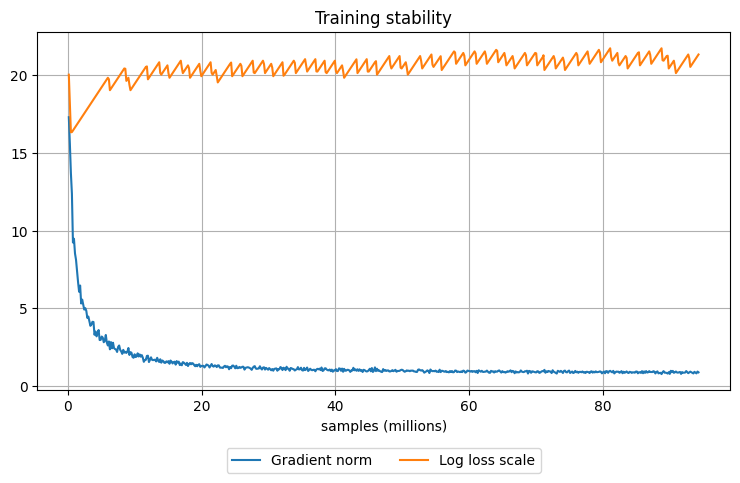

In [72]:
plot_stability(stage1_df2)

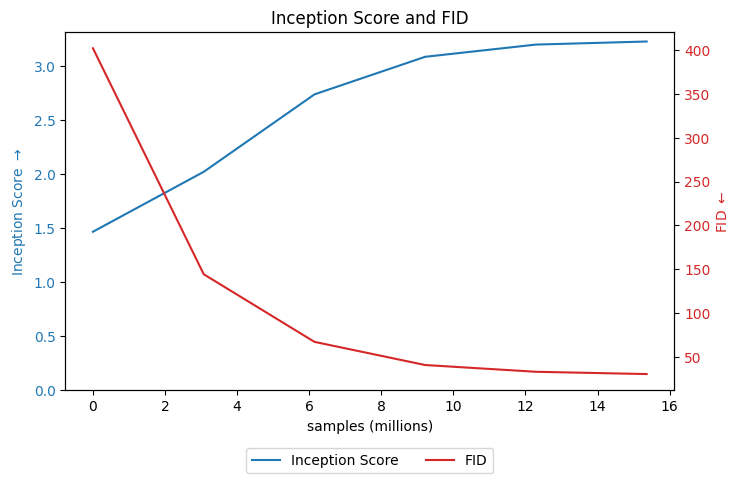

In [73]:
plot_is(stage1_df)

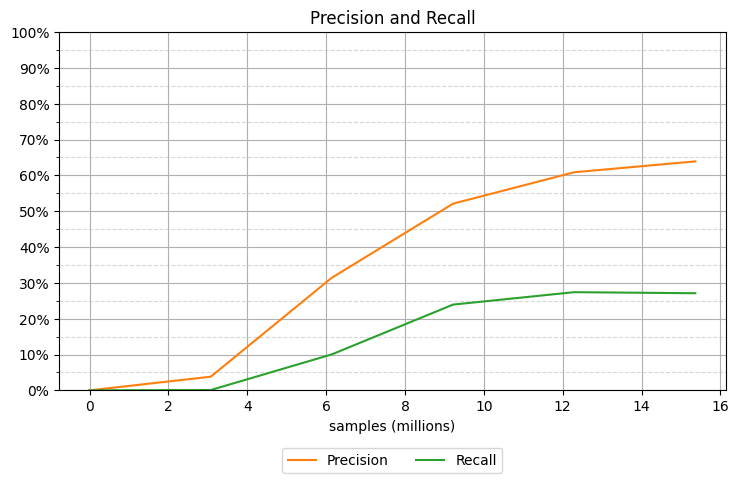

In [74]:
plot_prec_rec(stage1_df)

### Stage 2

In [75]:
try:
    stage2_df = pd.read_csv("stage2.csv")
    stage2_df = stage2_df.drop(columns=["fid_lower", "fid_upper", "sfid_lower", "sfid_upper"])
    print(f"Loaded stage2.csv — shape: {stage2_df.shape}")
    display(stage2_df.head())
except Exception as e:
    print(f"Error loading stage2.csv: {e}")

Loaded stage2.csv — shape: (43, 6)


,step,inception_score,fid_mean,sfid_mean,precision,recall
0,0,1.458297,188.56662,97.75565,0.00000,0.0
1,2000,1.460972,170.93524,99.92256,0.00004,0.0
2,4000,1.483020,154.17535,102.85075,0.00016,0.0
3,6000,1.514689,138.99174,103.45799,0.00076,0.0
4,8000,1.557302,125.62778,99.97919,0.00186,0.0


In [76]:
try:
    stage2_df2 = pd.read_csv("/home/bratosiewicz/data/last_stage2/11-03-pgd-ffhq-stage-2/progress.csv")
    stage2_df2 = stage2_df2.drop(columns=["discriminator_loss std", "recon_discriminator_loss std", "decoder_recon_loss std", "loss1_grad_norm std"])
    print(f"Loaded progress.csv — shape: {stage2_df2.shape}")
    display(stage2_df2.head())
except Exception as e:
    print(f"Error loading progress.csv: {e}")
    # create an empty DataFrame to avoid NameError later if df is used
    stage2_df2 = pd.DataFrame()

Loaded progress.csv — shape: (879, 9)


,decoder_recon_loss mean,discriminator_loss mean,grad_norm,lg_loss_scale,loss1_grad_norm mean,param_norm,recon_discriminator_loss mean,samples,step
0,0.588357,0.213286,19.336123,17.14162,0.484336,1345.558692,0.222120,12928,100
1,0.474321,0.123352,18.249348,17.07150,0.273066,1327.331251,0.120849,25728,200
2,0.362858,0.180235,31.633393,17.12150,0.260107,1327.346285,0.158184,38528,300
3,0.318501,0.180109,34.914132,17.17150,0.264791,1327.368786,0.252607,51328,400
4,0.299655,0.255419,34.905255,17.22150,0.281099,1327.396524,0.276205,64128,500


In [77]:
stage2_samples_for_df = np.interp(stage2_df['step'].values, stage2_df2['step'].values, stage2_df2['samples'].values)
stage2_samples_for_df[0] = 0.0
stage2_df['samples'] = stage2_samples_for_df
display(stage2_df.head())

,step,inception_score,fid_mean,sfid_mean,precision,recall,samples
0,0,1.458297,188.56662,97.75565,0.00000,0.0,0.0
1,2000,1.460972,170.93524,99.92256,0.00004,0.0,256128.0
2,4000,1.483020,154.17535,102.85075,0.00016,0.0,512128.0
3,6000,1.514689,138.99174,103.45799,0.00076,0.0,768128.0
4,8000,1.557302,125.62778,99.97919,0.00186,0.0,1024128.0


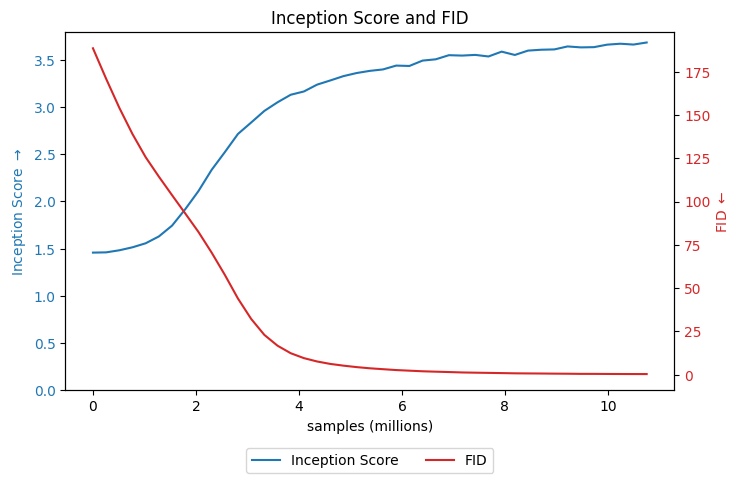

In [78]:
plot_is(stage2_df)

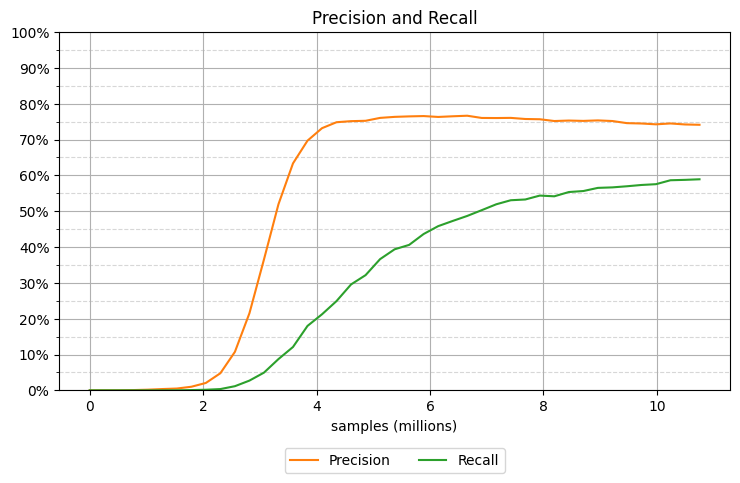

In [79]:
plot_prec_rec(stage2_df)

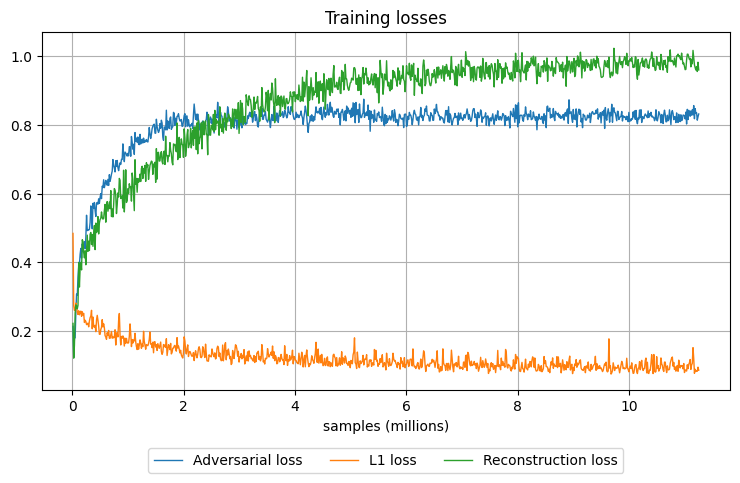

In [80]:
plot_losses(stage2_df2)

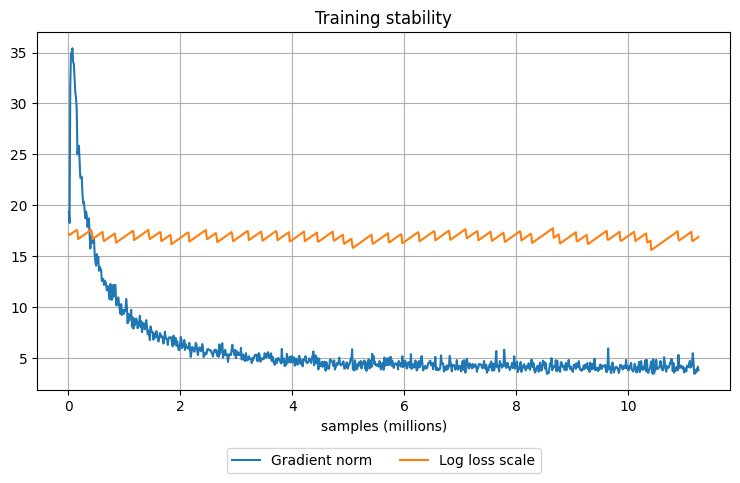

In [81]:
plot_stability(stage2_df2)

### Stage 3
#### a) 64->128

In [82]:
try:
    stage3a_df = pd.read_csv("stage3a.csv")
    # stage3a_df = stage3a_df.drop(columns=["fid_lower", "fid_upper", "sfid_lower", "sfid_upper"])
    print(f"Loaded stage3a.csv — shape: {stage3a_df.shape}")
    display(stage3a_df.head())
except Exception as e:
    print(f"Error loading stage3a.csv: {e}")
try:
    stage3a_df2 = pd.read_csv("/home/bratosiewicz/pagoda/out/11-09_ffhq_stage3_128/progress.csv")
    stage3a_df2 = stage3a_df2.drop(columns=["discriminator_loss std", "recon_discriminator_loss std", "decoder_recon_loss std", "loss1_grad_norm std"])
    print(f"Loaded progress.csv — shape: {stage3a_df2.shape}")
    display(stage3a_df2.head())
except Exception as e:
    print(f"Error loading progress.csv: {e}")
    # create an empty DataFrame to avoid NameError later if df is used
    stage3a_df2 = pd.DataFrame()

Loaded stage3a.csv — shape: (36, 5)


,step,inception_score,fid_mean,precision,recall
0,0,1.000015,270.998660,0.00000,0.0000
1,2000,1.061795,271.712220,0.00000,0.0000
2,4000,1.677743,171.345610,0.00770,0.0000
3,6000,1.953161,100.216194,0.10288,0.0007
4,8000,2.096766,72.903670,0.18888,0.0010


Loaded progress.csv — shape: (703, 9)


,decoder_recon_loss mean,discriminator_loss mean,grad_norm,lg_loss_scale,loss1_grad_norm mean,param_norm,recon_discriminator_loss mean,samples,step
0,0.719596,0.108991,24.845685,20.0245,0.000345,1226.616808,0.102309,6464,100
1,0.604130,0.046974,40.039973,20.0745,0.069662,1226.621761,0.053222,12864,200
2,0.356709,0.151778,31.035239,20.1245,0.114253,1226.631705,0.100814,19264,300
3,0.244580,0.041038,15.717265,20.1745,0.065400,1226.651816,0.061037,25664,400
4,0.194442,0.070404,12.420228,20.2245,0.051610,1226.667637,0.044862,32064,500


In [83]:
stage3a_samples_for_df = np.interp(stage3a_df['step'].values, stage3a_df2['step'].values, stage3a_df2['samples'].values)
stage3a_samples_for_df[0] = 0.0
stage3a_df['samples'] = stage3a_samples_for_df
display(stage3a_df.head())

,step,inception_score,fid_mean,precision,recall,samples
0,0,1.000015,270.998660,0.00000,0.0000,0.0
1,2000,1.061795,271.712220,0.00000,0.0000,128064.0
2,4000,1.677743,171.345610,0.00770,0.0000,256064.0
3,6000,1.953161,100.216194,0.10288,0.0007,384064.0
4,8000,2.096766,72.903670,0.18888,0.0010,512064.0


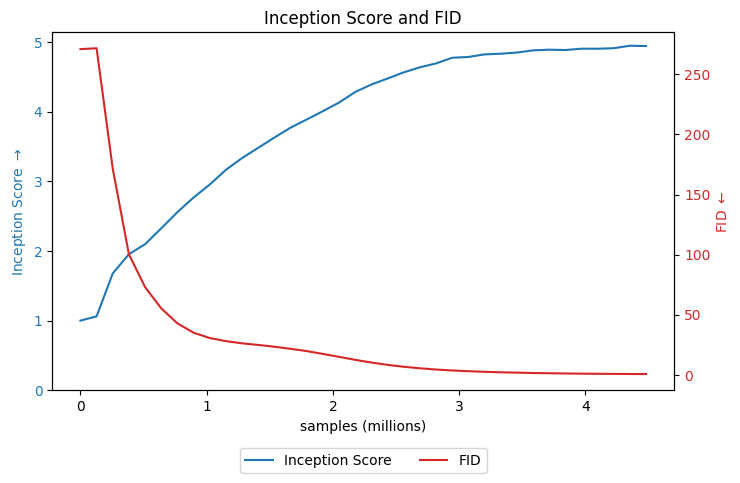

In [84]:
plot_is(stage3a_df)

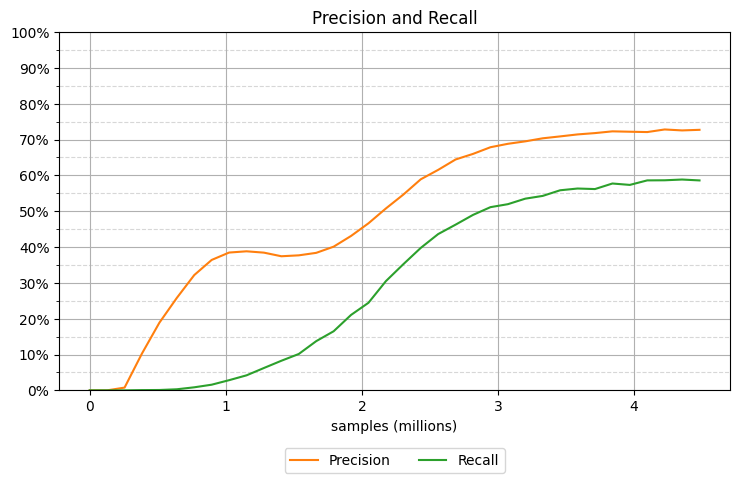

In [85]:
plot_prec_rec(stage3a_df)

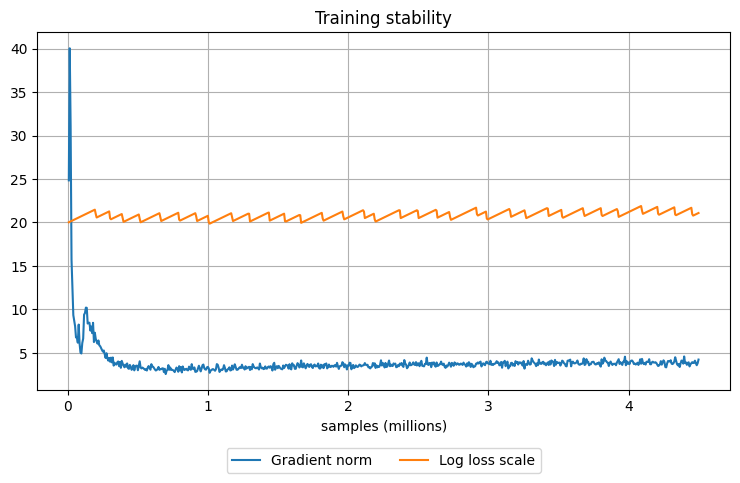

In [86]:
plot_stability(stage3a_df2)

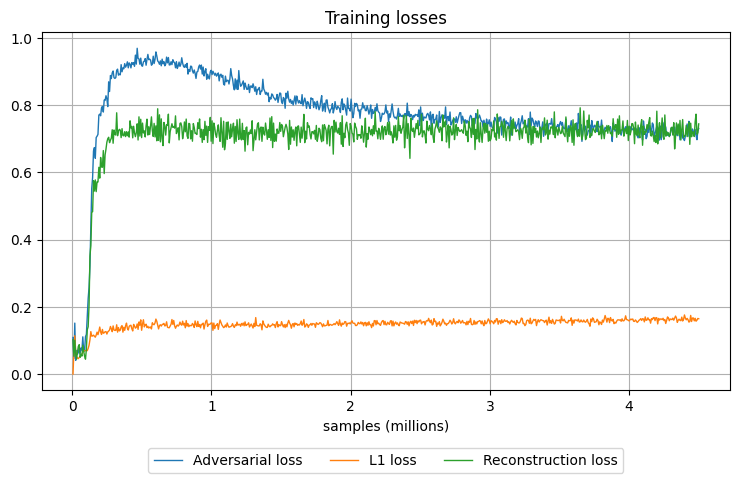

In [87]:
plot_losses(stage3a_df2)